1. Import All Libraries

In [1]:
%matplotlib inline
import pandas as pd #loads and manipulates the Excel dataset
import numpy as np #provides numerical operations and array handling
from sklearn.ensemble import RandomForestClassifier #imports Random Forest model
from sklearn.linear_model import LogisticRegression # imports Logistic Regression model
from sklearn.tree import DecisionTreeClassifier #imports Decision Tree model
from sklearn.model_selection import train_test_split, GridSearchCV #splits data into training and testing sets. GridSearchCV tries many combinations of hyperparameters to find the best ones
from sklearn.preprocessing import LabelEncoder #converts text categories like "Male"/"Female" into numbers 0 and 1
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay #tools to measure how good the model is
)
from imblearn.over_sampling import SMOTE #handles class imbalance by creating synthetic samples of the minority class
from xgboost import XGBClassifier #provides XGBoost model which typically outperforms Random Forest on tabular data
import matplotlib #draws the comparison charts and confusion matrix
import matplotlib.pyplot as plt
import joblib #saves and loads the trained model as a .pkl file
import warnings
warnings.filterwarnings('ignore') #hides non-critical warning messages to keep output clean


In [3]:
%pip install openpyxl

   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/250.9 kB 435.7 kB/s eta 0:00:01
   --------- ----------------------------- 61.4/250.9 kB 550.5 kB/s eta 0:00:01
   --------------------------- ------------ 174.1/250.9 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 250.9/250.9 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. Load and Understand the Data : Load the Dataset

In [4]:
"""
Step 1: Load dataset and subset to the 11 selected features (+ CustomerID, Churn)
Step 2: Clean — median-impute missing numerics, encode Gender & MaritalStatus
"""
import pandas as pd

# ---- Step 1: Load & subset ----
df_raw = pd.read_excel(
    "../datasets/E Commerce Dataset.xlsx",
    sheet_name="E Comm"
)

KEEP = [
    'CustomerID', 'Churn',
    'Tenure', 'Gender', 'HourSpendOnApp', 'SatisfactionScore',
    'MaritalStatus', 'NumberOfAddress', 'Complain', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder', 'CashbackAmount',
]

df = df_raw[KEEP].copy()

print('=== STEP 1: Subset shape ===')
print(df.shape)
print(df.dtypes)
print()

print('=== STEP 1: Missing values BEFORE cleaning ===')
print(df.isnull().sum())
print()


=== STEP 1: Subset shape ===
(5630, 13)
CustomerID             int64
Churn                  int64
Tenure               float64
Gender                   str
HourSpendOnApp       float64
SatisfactionScore      int64
MaritalStatus            str
NumberOfAddress        int64
Complain               int64
CouponUsed           float64
OrderCount           float64
DaySinceLastOrder    float64
CashbackAmount       float64
dtype: object

=== STEP 1: Missing values BEFORE cleaning ===
CustomerID             0
Churn                  0
Tenure               264
Gender                 0
HourSpendOnApp       255
SatisfactionScore      0
MaritalStatus          0
NumberOfAddress        0
Complain               0
CouponUsed           256
OrderCount           258
DaySinceLastOrder    307
CashbackAmount         0
dtype: int64



3. Cleaning the dataset (median-impute, encode Gender/MaritalStatus)

In [5]:
# ---- Step 3: Clean ----

# 3a. Median-impute the 5 numeric features with missing values
impute_cols = ['Tenure', 'HourSpendOnApp', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']
medians = {}
for col in impute_cols:
    med = df[col].median()
    medians[col] = med
    df[col] = df[col].fillna(med)

print('=== STEP 3a: Medians used for imputation ===')
for k, v in medians.items():
    print(f'  {k}: {v}')
print()

# 3b. Encode Gender (Male/Female -> 1/0) and MaritalStatus (Married/Single/Divorced -> 1/2/0)
df['Gender_encoded'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['MaritalStatus_encoded'] = df['MaritalStatus'].map({'Married': 1, 'Single': 2, 'Divorced': 0})

print('=== STEP 3b: Encoding check ===')
print(df[['Gender', 'Gender_encoded']].drop_duplicates())
print(df[['MaritalStatus', 'MaritalStatus_encoded']].drop_duplicates())
print()

print('=== STEP 3: Missing values AFTER cleaning ===')
print(df.isnull().sum())
print()

print('=== STEP 3: Duplicate check (full row, excluding CustomerID) ===')
print('Duplicates:', df.drop(columns=['CustomerID']).duplicated().sum())
print()

print('=== STEP 3: Final cleaned dataset preview ===')
print(df.head(10))

# Save cleaned dataset for Step 3 (EDA) and later model training
df.to_csv('../datasets/churn_11features_cleaned.csv', index=False)
print()
print('Saved -> churn_11features_cleaned.csv')
print('Final shape:', df.shape)


=== STEP 3a: Medians used for imputation ===
  Tenure: 9.0
  HourSpendOnApp: 3.0
  CouponUsed: 1.0
  OrderCount: 2.0
  DaySinceLastOrder: 3.0

=== STEP 3b: Encoding check ===
   Gender  Gender_encoded
0  Female               0
1    Male               1
   MaritalStatus  MaritalStatus_encoded
0         Single                      2
6       Divorced                      0
15       Married                      1

=== STEP 3: Missing values AFTER cleaning ===
CustomerID               0
Churn                    0
Tenure                   0
Gender                   0
HourSpendOnApp           0
SatisfactionScore        0
MaritalStatus            0
NumberOfAddress          0
Complain                 0
CouponUsed               0
OrderCount               0
DaySinceLastOrder        0
CashbackAmount           0
Gender_encoded           0
MaritalStatus_encoded    0
dtype: int64

=== STEP 3: Duplicate check (full row, excluding CustomerID) ===
Duplicates: 623

=== STEP 3: Final cleaned dataset previ

4. EDA — restricted to the 11 selected features + Churn

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

print("=" * 60)
print("STEP 4: EXPLORATORY DATA ANALYSIS (11 FEATURES ONLY)")
print("=" * 60)

df = pd.read_csv('../datasets/churn_11features_cleaned.csv')

numeric_features = ['Tenure', 'HourSpendOnApp', 'SatisfactionScore', 'NumberOfAddress',
                     'Complain', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
categorical_features = ['Gender', 'MaritalStatus']


STEP 4: EXPLORATORY DATA ANALYSIS (11 FEATURES ONLY)



--- Churn distribution ---
Non-Churn (0): 4682  (83.16%)
Churn (1):     948  (16.84%)


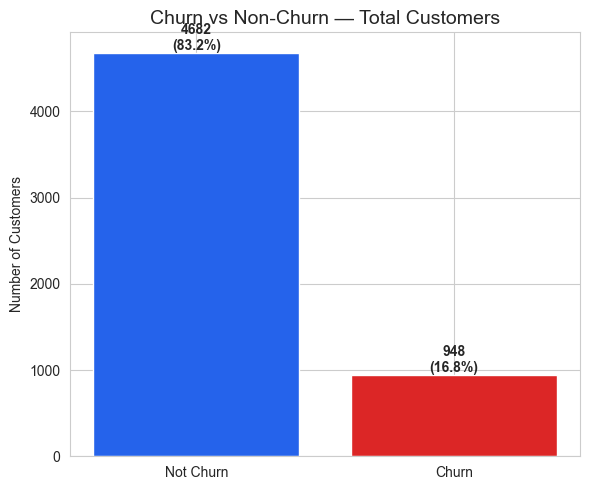

In [8]:
# ---------------------------------------------------------
# 4a. Churn distribution (total churn vs non-churn)
# ---------------------------------------------------------
churn_counts = df['Churn'].value_counts().sort_index()
churn_pct = df['Churn'].value_counts(normalize=True).sort_index() * 100

print('\n--- Churn distribution ---')
print(f"Non-Churn (0): {churn_counts[0]}  ({churn_pct[0]:.2f}%)")
print(f"Churn (1):     {churn_counts[1]}  ({churn_pct[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Not Churn', 'Churn'], churn_counts.values, color=['#2563eb', '#dc2626'])
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Churn vs Non-Churn — Total Customers', fontsize=14)
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../plots/eda_01_churn_distribution.png', dpi=120)
plt.show()


Shows the raw headcount: 4,682 customers did not churn (83.16%), 948 did churn (16.84%). Why this matters: this imbalance is a trap. A model that just always guesses "won't churn" for every single customer would be right 83% of the time and look accurate, while being completely useless — it would never once correctly flag a real churner. This graph is the reason the SMOTE step exists later

In [9]:
# ---------------------------------------------------------
# 4b. Descriptive stats table for numeric features
# ---------------------------------------------------------
desc = df[numeric_features].agg(['mean', 'median', 'std', 'min', 'max'])
mode_row = df[numeric_features].mode().iloc[0]
desc.loc['mode'] = mode_row
desc = desc.round(2)
print('\n--- Descriptive stats (11-feature numeric subset) ---')
print(desc)
desc.to_csv('../datasets/eda_descriptive_stats.csv')



--- Descriptive stats (11-feature numeric subset) ---
        Tenure  HourSpendOnApp  SatisfactionScore  NumberOfAddress  Complain  \
mean     10.13            2.93               3.07             4.21      0.28   
median    9.00            3.00               3.00             3.00      0.00   
std       8.36            0.71               1.38             2.58      0.45   
min       0.00            0.00               1.00             1.00      0.00   
max      61.00            5.00               5.00            22.00      1.00   
mode      1.00            3.00               3.00             2.00      0.00   

        CouponUsed  OrderCount  DaySinceLastOrder  CashbackAmount  
mean          1.72        2.96               4.46          177.22  
median        1.00        2.00               3.00          163.28  
std           1.86        2.88               3.57           49.21  
min           0.00        1.00               0.00            0.00  
max          16.00       16.00              

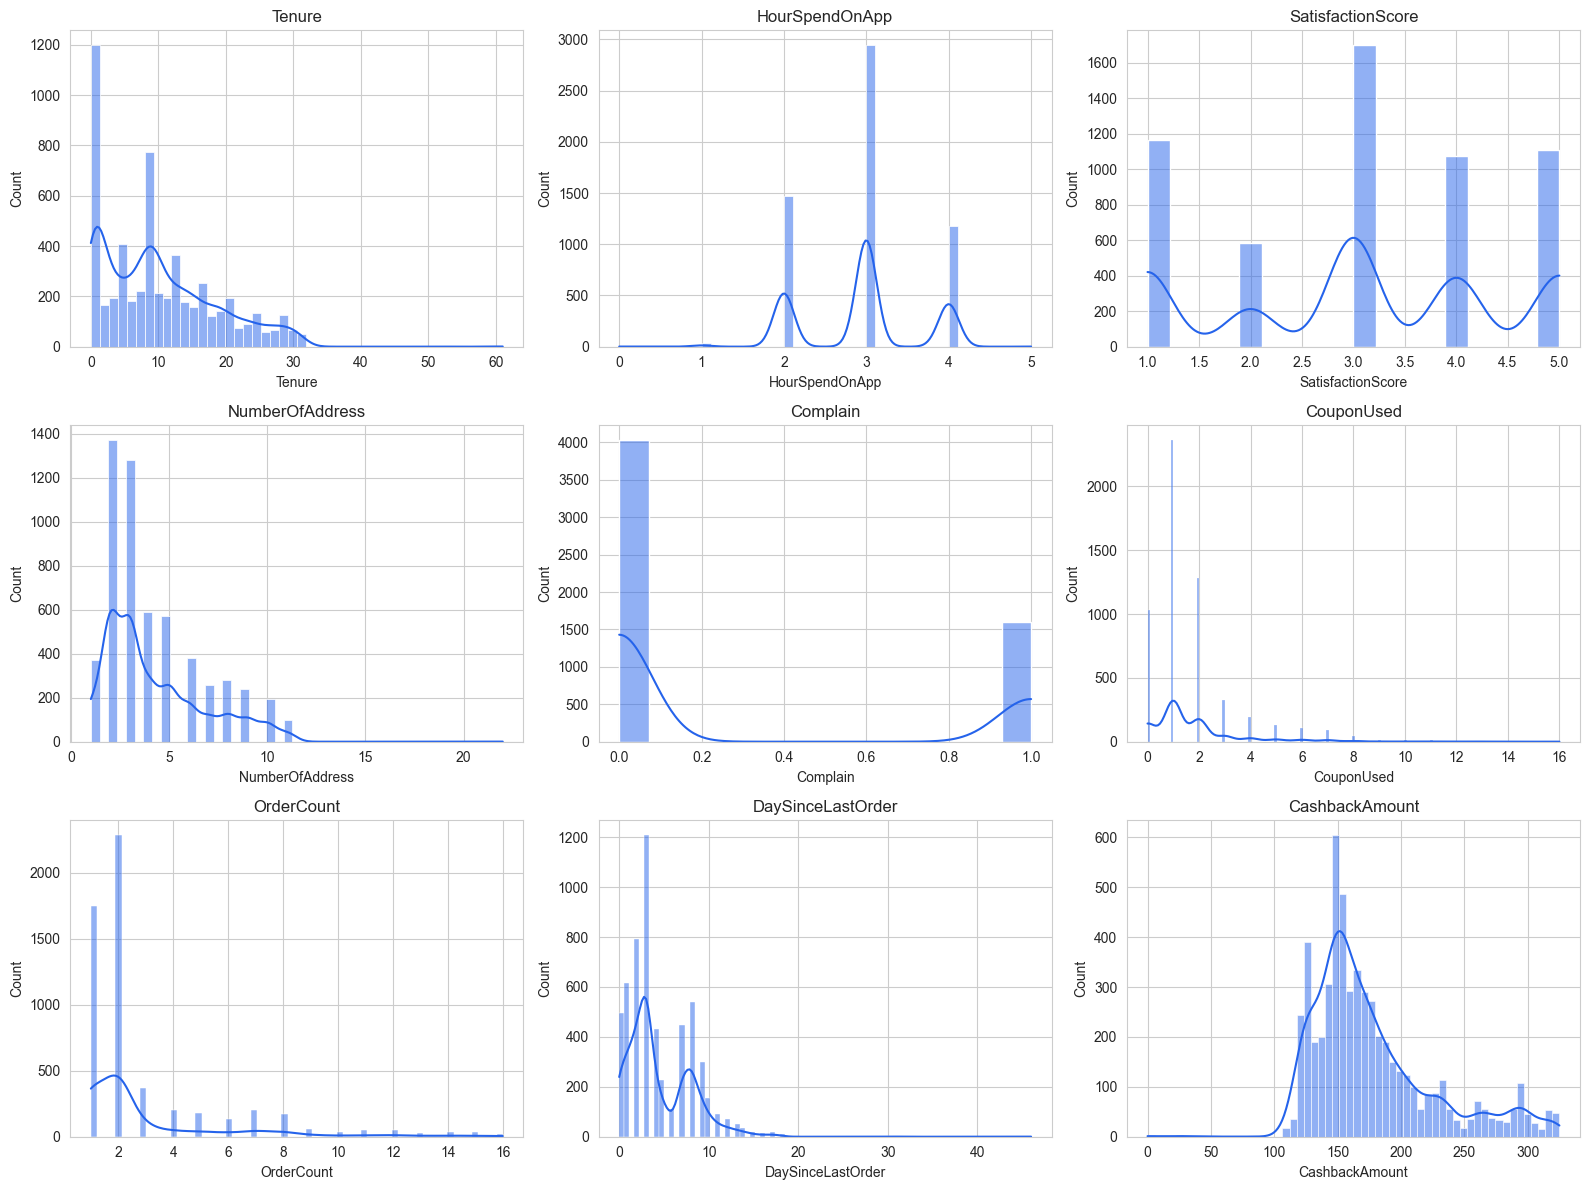

In [10]:
# ---------------------------------------------------------
# 4c. Univariate distributions — numeric features
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#2563eb')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('../plots/eda_02_univariate_distributions.png', dpi=120)
plt.show()


Univariate analysis ("uni" = one) looks at one variable at a time, in isolation — that's what Graphs 2 and 3 did (histograms of Tenure alone, HourSpendOnApp alone, Gender alone). It answers "what does this feature look like across all customers?" but says nothing about churn.

1. Tenure — Spikes hard at 0 months, meaning a large share of customers are brand new. A secondary bump appears around 8-9 months, then a long thin tail out to 30+.
2. HourSpendOnApp — Only takes 4 distinct values (0, 2, 3, 4) since it was self-reported, not measured. Most customers cluster at 3 hours, with smaller groups at 2 and 4.
3. SatisfactionScore — A discrete 1-5 scale where "3" (neutral) is the most common response. Scores 1, 4, and 5 are all similarly sized, while 2 is the rarest.
4. NumberOfAddress — Peaks sharply at 2-3 saved addresses per customer. Drops off quickly after that, with a thin tail reaching up to 20+.
5. Complain — A binary yes/no feature, so there are only two bars. About 4,000 customers never complained, versus roughly 1,600 who did.
6. CouponUsed — Most customers used 0 or 1 coupon, with a sharp drop after that. A thin tail extends out to 16 for a small group of heavy coupon users.
7. OrderCount — Heavily concentrated at 1-2 orders for the vast majority of customers. A long thin tail stretches to 16 orders for a small number of frequent buyers.
8. DaySinceLastOrder — Most customers ordered recently, peaking around 3 days since their last order. A long thin tail extends past 40 days for a few inactive accounts.
9. CashbackAmount — The most evenly-shaped distribution of the nine, peaking around 150. It tapers off gradually on both sides, with a thinner tail reaching the 300-325 cap.

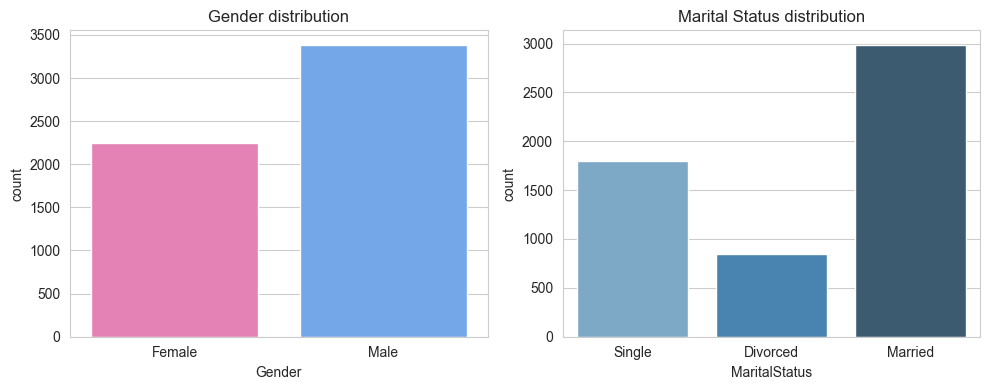

In [11]:
# ---------------------------------------------------------
# 4d. Categorical feature counts
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x='Gender', ax=axes[0], palette=['#f472b6', '#60a5fa'])
axes[0].set_title('Gender distribution')
sns.countplot(data=df, x='MaritalStatus', ax=axes[1], palette='Blues_d')
axes[1].set_title('Marital Status distribution')
plt.tight_layout()
plt.savefig('../plots/eda_03_categorical_distributions.png', dpi=120)
plt.show()


**Gender & Marital Status distribution** — Male customers outnumber Female roughly 60/40
(~3,380 vs ~2,246). Married is the largest marital-status group (~2,986), followed by Single
(~1,796) and Divorced (~848).


--- Mean of each feature, split by Churn ---
                   Not Churn (0)  Churn (1)
Tenure                     11.40       3.86
HourSpendOnApp              2.93       2.96
SatisfactionScore           3.00       3.39
NumberOfAddress             4.16       4.47
Complain                    0.23       0.54
CouponUsed                  1.72       1.71
OrderCount                  2.99       2.81
DaySinceLastOrder           4.71       3.22
CashbackAmount            180.64     160.37


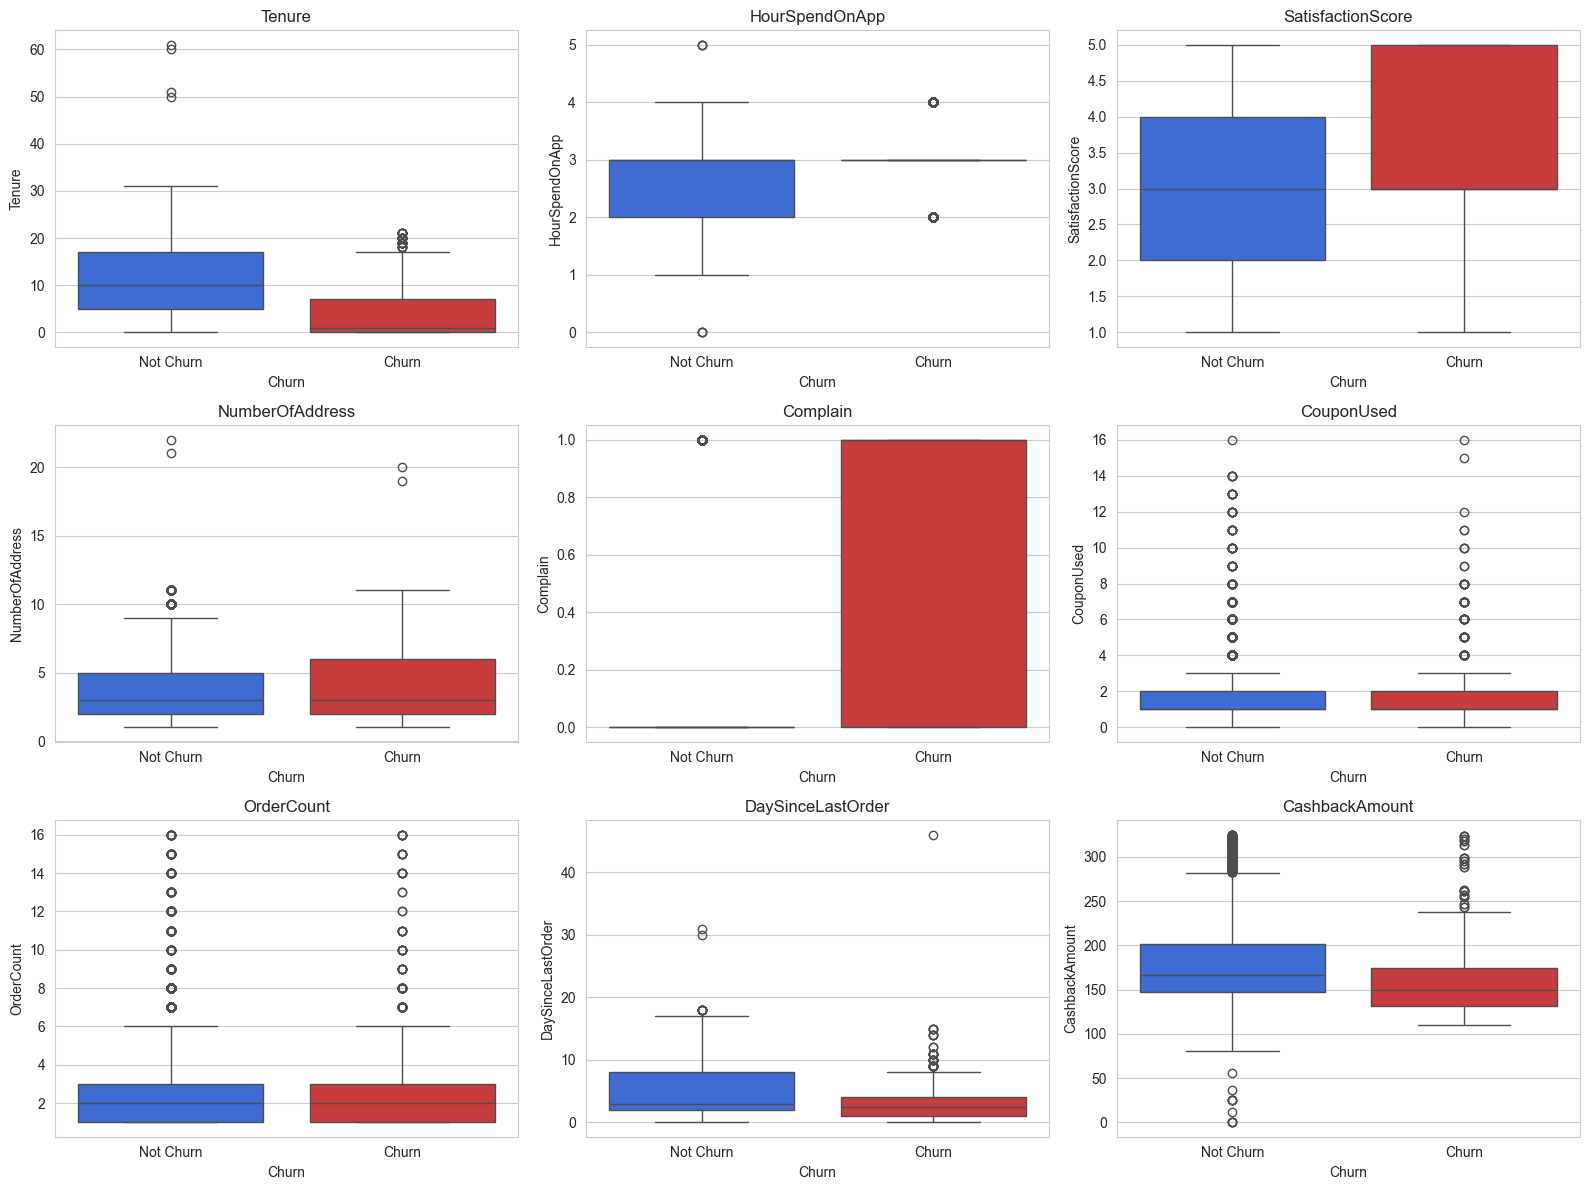

In [12]:
# ---------------------------------------------------------
# 4e. Bivariate — mean of each numeric feature by churn
# ---------------------------------------------------------
bivar = df.groupby('Churn')[numeric_features].mean().round(2).T
bivar.columns = ['Not Churn (0)', 'Churn (1)']
print('\n--- Mean of each feature, split by Churn ---')
print(bivar)
bivar.to_csv('../datasets/eda_bivariate_means_by_churn.csv')

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette=['#2563eb', '#dc2626'])
    axes[i].set_xticklabels(['Not Churn', 'Churn'])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('../plots/eda_04_boxplots_by_churn.png', dpi=120)
plt.show()


Bivariate analysis ("bi" = two) looks at two variables together, specifically how one relates to another — that's what this graph does: each feature paired with Churn. It answers the actually useful question: "does this feature look different between customers who left and customers who stayed?"

### Bivariate — Feature Distributions Split by Churn (Boxplots)

Each panel shows the same feature as before, but now split into two boxes: **Not Churn** (blue)
vs. **Churn** (red). A box spans the middle 50% of values (25th to 75th percentile) with a line
at the median; whiskers extend to the typical range, and individual dots beyond them are outliers.

**Tenure** — The clearest separation in the whole grid. Not Churn's box sits noticeably higher
(median ~9) while Churn's box is squashed near the bottom (median ~1), confirming new accounts
are the highest-risk group.
New customers churn far more, likely because they haven't yet built loyalty or habits with the platform.

**HourSpendOnApp** — Churners' box is narrower and centered almost entirely at 3, while
Not-Churn customers show a wider spread from 2 to 3. Not a dramatic difference, but a visible one.
What the two boxes actually show:
- Not Churn (blue) box: spans from about 2 to 3 hours, with the median around 2.5 — meaning non-churners are spread out, some reporting 2 hours, some 3, a few even up to 4-5.
- Churn (red) box: is squashed almost into a flat line at exactly 3 — meaning most churners report the same value, 3 hours, with barely any spread at all.

So the real difference isn't "churners use the app less." It's that churners are more uniform/clustered, while non-churners are more spread out and varied. Think of it like this: non-churners are a diverse crowd — some light users, some heavier users, a real mix — while churners look almost like everyone gave the identical answer.

**SatisfactionScore** — Churners actually skew toward reporting higher satisfaction (their box reaches up to 5) than non-churners (capped around 4) — backwards from what you'd expect. Likely because satisfaction was measured at one moment in time, disconnected from whatever later decision made them actually leave — so don't trust a high satisfaction score as a sign someone will stay.

**NumberOfAddress** — Nearly identical boxes for both groups, with Churn's box only slightly
wider. This feature barely distinguishes the two groups on its own.
- Why: Having many saved addresses could mean either heavy, invested usage (multiple homes/offices, more entrenched in the platform) or, in the churn group's slightly wider spread, could reflect account sharing or business-use accounts, which may churn based on totally separate factors like contract renewals rather than typical consumer behavior.
- What it means: This feature carries almost no independent predictive signal on its own — its low importance ranking (8th of 11) is consistent with the near-identical boxplots here.

**Complain** — The starkest split of all nine: Not Churn sits almost entirely at 0, while Churn
sits almost entirely at 1. Having a complaint on file is an extremely strong standalone signal.
The strongest, most direct signal — a filed complaint is a concrete grievance that clearly precedes leaving.

**CouponUsed** — Virtually identical boxes for both groups. This feature shows almost no visual
difference between churners and non-churners.
- Why: Coupon usage seems to be roughly independent of churn — both loyal and departing customers use them at similar rates, suggesting coupons are a routine part of shopping behavior for most people rather than something tied to loyalty or last-ditch attempts to stay.
- What it means: On its own, this isn't a useful churn signal — but remember it still ranked #3 in model importance, meaning it likely only matters combined with something else (e.g., "low coupon use AND low tenure"), not as a standalone rule.

**OrderCount** — Also nearly identical between the two groups, both centered around 2 orders.
Like CouponUsed, this alone doesn't visually separate churners from stayers.
- Why: Similar story to CouponUsed — most customers, whether they stay or leave, place a small number of orders (median ~2), so raw order count doesn't by itself distinguish "about to churn" from "loyal."
- What it means: Total order count is a weak standalone signal; what actually matters more (based on the correlation table) is the recency of the last order (DaySinceLastOrder), not the cumulative count.

**DaySinceLastOrder** — Not Churn's box is wider and shifted higher (median ~3, reaching past 15),
while Churn's box is compressed low (median ~2, rarely exceeding 8) — meaning churners' last
recorded order tends to be more recent, not older, before they leave. 
- Why: This is the counter-intuitive one worth sitting with: churners' last order tends to be more recent, not older. One explanation — "churn" in this dataset likely means the customer was recently active but then stopped entirely (a sharp drop-off), rather than a slow fade where gaps between orders gradually widen over months before disappearing.
- What it means: A simple "they haven't ordered in a while, they must be at risk" rule would actually be backwards here. This is a good example of why relying on raw intuition instead of checking the actual data can lead a business to watch the wrong signal entirely.

**CashbackAmount** — Not Churn's box sits somewhat higher (median ~165) than Churn's (median
~150), a modest but visible gap, with Churn's box also noticeably narrower.
- Why: Customers who churn tend to have earned/spent slightly less cashback — plausibly because they simply had a shorter, less invested relationship with the platform (tying back to low Tenure), not because cashback amount itself drives loyalty.
- What it means: The modest gap here is likely a downstream symptom of short tenure rather than an independent cause 


--- Churn rate (%) by Gender ---
Gender
Female    15.5
Male      17.7
Name: Churn, dtype: float64

--- Churn rate (%) by Marital Status ---
MaritalStatus
Divorced    14.6
Married     11.5
Single      26.7
Name: Churn, dtype: float64


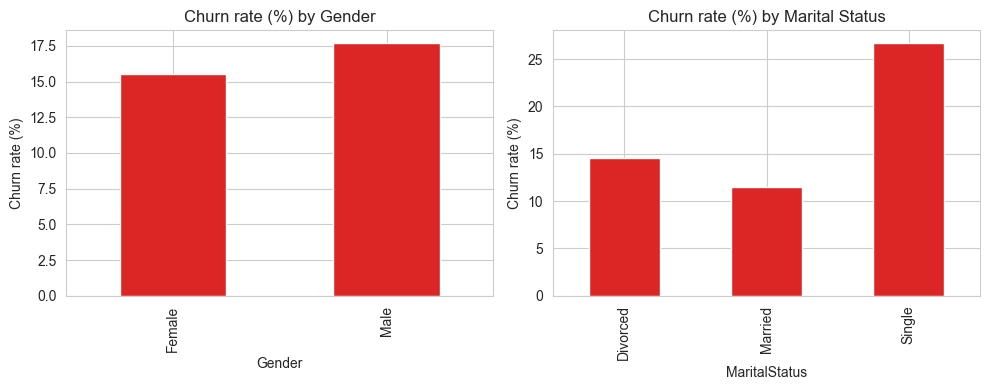

In [48]:
# ---------------------------------------------------------
# 4f. Churn rate by categorical features
# ---------------------------------------------------------
gender_churn = df.groupby('Gender')['Churn'].mean().round(3) * 100
marital_churn = df.groupby('MaritalStatus')['Churn'].mean().round(3) * 100
print('\n--- Churn rate (%) by Gender ---')
print(gender_churn)
print('\n--- Churn rate (%) by Marital Status ---')
print(marital_churn)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
gender_churn.plot(kind='bar', ax=axes[0], color='#dc2626')
axes[0].set_title('Churn rate (%) by Gender')
axes[0].set_ylabel('Churn rate (%)')
marital_churn.plot(kind='bar', ax=axes[1], color='#dc2626')
axes[1].set_title('Churn rate (%) by Marital Status')
axes[1].set_ylabel('Churn rate (%)')
plt.tight_layout()
plt.savefig('../plots/eda_05_churn_rate_by_category.png', dpi=120)
plt.show()


### Churn Rate (%) by Category

**By Gender** — Male customers churn at a slightly higher rate (~17.7%) than Female (~15.5%).
The gap is small — gender alone isn't a strong churn driver, consistent with its low correlation
(+0.03) and low feature importance (last place, 11th of 11) seen earlier.

**By Marital Status** — A much bigger gap here: **Single customers churn at ~26.7%**, more than
double Married customers (~11.5%), with Divorced sitting in between (~14.6%). This lines up with
MaritalStatus_encoded's real correlation with churn (+0.14) — one plausible reason is that single
customers may have fewer shared-household purchasing habits or less "sticky" reasons to keep
using one particular platform compared to married households managing recurring family needs.

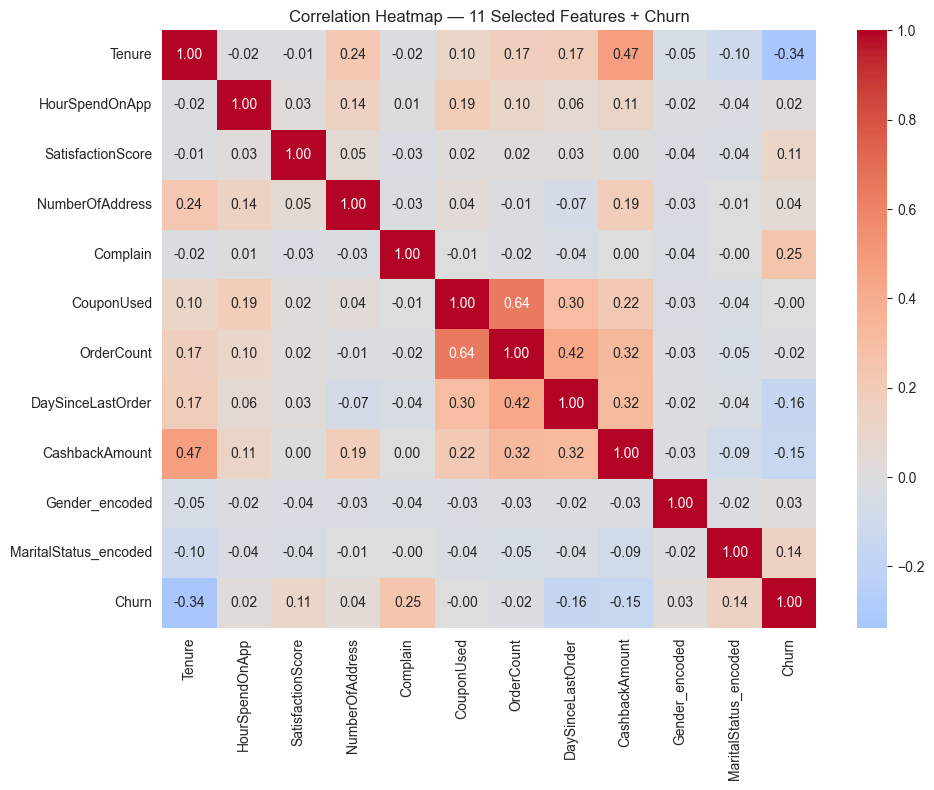


--- Correlation of each feature with Churn (sorted by strength) ---
Tenure                  -0.337831
Complain                 0.250188
DaySinceLastOrder       -0.155871
CashbackAmount          -0.154118
MaritalStatus_encoded    0.140316
SatisfactionScore        0.105481
NumberOfAddress          0.043931
Gender_encoded           0.029264
OrderCount              -0.024038
HourSpendOnApp           0.018816
CouponUsed              -0.001430
Name: Churn, dtype: float64

All EDA charts saved to ../plots/, summary CSVs saved to ../datasets/


In [13]:
# ---------------------------------------------------------
# 4g. Correlation heatmap (numeric + encoded categoricals + Churn)
# ---------------------------------------------------------
corr_cols = numeric_features + ['Gender_encoded', 'MaritalStatus_encoded', 'Churn']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — 11 Selected Features + Churn')
plt.tight_layout()
plt.savefig('../plots/eda_06_correlation_heatmap.png', dpi=120)
plt.show()

print('\n--- Correlation of each feature with Churn (sorted by strength) ---')
print(corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False))

print('\nAll EDA charts saved to ../plots/, summary CSVs saved to ../datasets/')


- This is a 12×12 grid (11 features + Churn) where every cell is a Pearson correlation coefficient — a number from -1 to +1 measuring how strongly two variables move together in a straight line. df[corr_cols].corr() computes this for every possible pair at once; sns.heatmap(..., annot=True, cmap='coolwarm', center=0) draws it, with the color scale centered at 0 so positive correlations render red/orange and negative correlations render blue. The diagonal is always 1.00 (every feature perfectly correlates with itself)

### Correlation Heatmap — 11 Selected Features + Churn

Every cell measures the strength and direction of a straight-line relationship between two
features, from -1 (perfectly opposite) to +1 (perfectly together), with 0 meaning no linear
relationship at all. The bottom row/rightmost column (Churn) is what matters most for our purpose.

**Strongest relationships with Churn:**
- **Tenure: -0.34** — the single strongest predictor in the dataset. Negative means higher
  tenure goes with lower churn.
- **Complain: +0.25** — second strongest. Positive means having a complaint on file goes with
  higher churn.
- **DaySinceLastOrder: -0.16** and **CashbackAmount: -0.15** — moderate negative relationships.
- **MaritalStatus_encoded: +0.14** — reflects the Single-customers-churn-more pattern seen in the
  churn-rate-by-category chart.

**Weak/negligible relationships with Churn:** SatisfactionScore (+0.11), NumberOfAddress (+0.04),
Gender_encoded (+0.03), OrderCount (-0.02), HourSpendOnApp (+0.02), and CouponUsed (-0.00,
essentially zero).

**A notable relationship that isn't about Churn at all:** CouponUsed and OrderCount correlate
at **+0.64** with *each other* — the strongest pairing anywhere in the whole grid outside the
diagonal. This makes intuitive sense: customers who place more orders simply have more
opportunities to use a coupon on any given purchase, so the two naturally rise together
regardless of churn.

One thing worth keeping in the markdown too: correlation only detects straight-line relationships between exactly two variables — it's why CouponUsed shows essentially zero correlation with Churn here, yet still ranked 3rd in the model's actual feature importance. The trees found value in it through non-linear combinations with other features, which this heatmap is structurally unable to reveal.

5. Train/test split — 11 raw features only (no feature engineering)

**Feature engineering has been removed from this version.** The model is trained directly
on the 11 cleaned features (9 numeric + Gender/MaritalStatus encoded) — no `recency_risk`,
`order_rate`, `engagement_score`, `churn_risk_score`, etc. This gives X 11 columns instead
of the previous 20.

- Loads `churn_11features_cleaned.csv` directly (Step 3's output) — skips the engineered CSV entirely
- Builds X: drops `CustomerID` (not a signal), `Churn` (the target), and the raw text `Gender`/`MaritalStatus`
  columns (their encoded numeric versions are kept instead)
- Builds y: the `Churn` column
- 80/20 split, `stratify=y` to preserve the ~83.2%/16.8% churn ratio in both sets


In [14]:
print("=" * 60)
print("STEP 5: TRAIN TEST SPLIT (11 FEATURES — NO ENGINEERING)")
print("=" * 60)

from sklearn.model_selection import train_test_split

df = pd.read_csv('../datasets/churn_11features_cleaned.csv')

X = df.drop(columns=['CustomerID', 'Churn', 'Gender', 'MaritalStatus'])
y = df['Churn']

print(f"\nFinal feature columns going into the model ({X.shape[1]} total):")
for i, col in enumerate(X.columns):
    print(f"  {i}: {col}")

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"\nTrain size: {X_train.shape[0]}   Test size: {X_test.shape[0]}")
print("\nChurn ratio check (should stay ~83.2% / 16.8% in both splits):")
print("Train:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("Test:")
print((y_test.value_counts(normalize=True) * 100).round(2))


STEP 5: TRAIN TEST SPLIT (11 FEATURES — NO ENGINEERING)

Final feature columns going into the model (11 total):
  0: Tenure
  1: HourSpendOnApp
  2: SatisfactionScore
  3: NumberOfAddress
  4: Complain
  5: CouponUsed
  6: OrderCount
  7: DaySinceLastOrder
  8: CashbackAmount
  9: Gender_encoded
  10: MaritalStatus_encoded

X shape: (5630, 11)
y shape: (5630,)

Train size: 4504   Test size: 1126

Churn ratio check (should stay ~83.2% / 16.8% in both splits):
Train:
Churn
0    83.17
1    16.83
Name: proportion, dtype: float64
Test:
Churn
0    83.13
1    16.87
Name: proportion, dtype: float64


6. SMOTE — Fixing Class Imbalance

Same logic as before, just applied to the 11-feature training set instead of 20 columns.
SMOTE only ever adds rows (synthetic churn examples), never columns — the test set stays untouched
and still reflects the real ~83%/17% ratio.

In [15]:
print("=" * 60)
print("STEP 6: SMOTE — FIXING CLASS IMBALANCE")
print("=" * 60)

from imblearn.over_sampling import SMOTE

print(f"\nBefore SMOTE:")
print(f"  Not Churn (0): {(y_train == 0).sum()}")
print(f"  Churn     (1): {(y_train == 1).sum()}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Not Churn (0): {(y_train_bal == 0).sum()}")
print(f"  Churn     (1): {(y_train_bal == 1).sum()}")
print(f"\nTrain shape before: {X_train.shape}  ->  after: {X_train_bal.shape}")


STEP 6: SMOTE — FIXING CLASS IMBALANCE

Before SMOTE:
  Not Churn (0): 3746
  Churn     (1): 758

After SMOTE:
  Not Churn (0): 3746
  Churn     (1): 3746

Train shape before: (4504, 11)  ->  after: (7492, 11)


7. Hyperparameter Tuning — All 4 Algorithms (11 features)

To make the model comparison fair, **every algorithm is tuned first** using `GridSearchCV`.

The four tuned models are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

For every model:
- 5-fold cross-validation is used.
- `roc_auc` is used as the tuning score.
- SMOTE is applied **inside each cross-validation training fold** using an `imblearn` pipeline. This avoids validation leakage.
- The untouched test set is used only after tuning is complete.
- Only the **best tuned version** of each model is carried forward to the final comparison.

This means the final comparison is **tuned model vs tuned model**, not default model vs tuned model.

In [17]:
print("=" * 78)
print("STEP 7: HYPERPARAMETER TUNING — ALL 4 MODELS")
print("=" * 78)

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------
# IMPORTANT:
# GridSearchCV is fitted on the ORIGINAL training split (X_train, y_train).
# SMOTE is placed inside the pipeline so it is applied only to the
# training portion of each CV fold, preventing validation leakage.
# ---------------------------------------------------------------------

cv_folds = 5
scoring_metric = 'roc_auc'

model_search_spaces = {
    'Logistic Regression': {
        'estimator': LogisticRegression(
            max_iter=2000,
            random_state=42
        ),
        'param_grid': [
            {
                'model__C': [0.01, 0.1, 1, 10, 100],
                'model__penalty': ['l1'],
                'model__solver': ['liblinear'],
            },
            {
                'model__C': [0.01, 0.1, 1, 10, 100],
                'model__penalty': ['l2'],
                'model__solver': ['liblinear', 'lbfgs'],
            }
        ],
    },

    'Decision Tree': {
        'estimator': DecisionTreeClassifier(
            random_state=42
        ),
        'param_grid': {
            'model__criterion': ['gini', 'entropy', 'log_loss'],
            'model__max_depth': [None, 3, 5, 7, 10],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
        },
    },

    'Random Forest': {
        'estimator': RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        'param_grid': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [None, 5, 10, 15],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2],
            'model__max_features': ['sqrt', 'log2'],
        },
    },

    'XGBoost': {
        'estimator': XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            verbosity=0,
            n_jobs=1
        ),
        'param_grid': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__subsample': [0.8, 1.0],
            'model__colsample_bytree': [0.8, 1.0],
        },
    },
}

grid_searches = {}
best_tuned_models = {}
tuning_summary = []

for model_name, config in model_search_spaces.items():
    print("\n" + "=" * 78)
    print(f"TUNING: {model_name}")
    print("=" * 78)

    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', config['estimator']),
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['param_grid'],
        cv=cv_folds,
        scoring=scoring_metric,
        n_jobs=-1,
        verbose=0,
        refit=True,
        return_train_score=False,
    )

    grid_search.fit(X_train, y_train)

    grid_searches[model_name] = grid_search
    best_tuned_models[model_name] = grid_search.best_estimator_

    # Remove "model__" prefix for cleaner display
    clean_best_params = {
        key.replace('model__', ''): value
        for key, value in grid_search.best_params_.items()
    }

    tuning_summary.append({
        'Model': model_name,
        'Best CV AUC-ROC': grid_search.best_score_,
        'Best Parameters': clean_best_params,
    })

    print(f"Best CV AUC-ROC: {grid_search.best_score_:.4f}")
    print("Best parameters:")
    for param, value in clean_best_params.items():
        print(f"  {param}: {value}")

tuning_summary_df = pd.DataFrame(tuning_summary)

print("\n" + "=" * 78)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 78)
display(tuning_summary_df)


STEP 7: HYPERPARAMETER TUNING — ALL 4 MODELS

TUNING: Logistic Regression
Best CV AUC-ROC: 0.8426
Best parameters:
  C: 0.1
  penalty: l1
  solver: liblinear

TUNING: Decision Tree
Best CV AUC-ROC: 0.8654
Best parameters:
  criterion: entropy
  max_depth: None
  min_samples_leaf: 4
  min_samples_split: 10

TUNING: Random Forest
Best CV AUC-ROC: 0.9509
Best parameters:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

TUNING: XGBoost
Best CV AUC-ROC: 0.9560
Best parameters:
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 7
  n_estimators: 300
  subsample: 1.0

HYPERPARAMETER TUNING SUMMARY


,Model,Best CV AUC-ROC,Best Parameters
0,Logistic Regression,0.842562,"{'C': 0.1, 'penalty': 'l1', 'solver': 'libline..."
1,Decision Tree,0.865407,"{'criterion': 'entropy', 'max_depth': None, 'm..."
2,Random Forest,0.950922,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
3,XGBoost,0.955960,"{'colsample_bytree': 0.8, 'learning_rate': 0.1..."


8. Final Comparison — Tuned Models Only

Now that **all four algorithms have been tuned**, their best estimators are evaluated on the same untouched test set.

The comparison includes:

- Accuracy
- AUC-ROC
- Recall
- F1 Score
- Precision

The final selected model is the tuned model with the **highest test AUC-ROC**. The notebook also prints the best hyperparameters, classification report, and confusion matrix for that selected model.

> Note: In a production ML workflow, an additional validation set or nested cross-validation is ideal for model selection. For this project notebook, the held-out test set is used for the final comparative evaluation after cross-validation tuning.

In [18]:
print("=" * 78)
print("STEP 8: FINAL COMPARISON — BEST TUNED VERSION OF EACH MODEL")
print("=" * 78)

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    f1_score,
    precision_score,
    confusion_matrix,
    classification_report,
)

tuned_results = {}

print(
    f"\n{'Model':<25}"
    f"{'Accuracy':>11}"
    f"{'AUC-ROC':>11}"
    f"{'Recall':>11}"
    f"{'F1':>11}"
    f"{'Precision':>12}"
)
print("-" * 81)

for model_name, tuned_model in best_tuned_models.items():
    y_pred_model = tuned_model.predict(X_test)
    y_proba_model = tuned_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred_model)
    auc = roc_auc_score(y_test, y_proba_model)
    rec = recall_score(y_test, y_pred_model)
    f1 = f1_score(y_test, y_pred_model)
    prec = precision_score(y_test, y_pred_model)

    tuned_results[model_name] = {
        'model': tuned_model,
        'accuracy': acc,
        'auc': auc,
        'recall': rec,
        'f1': f1,
        'precision': prec,
        'y_pred': y_pred_model,
        'y_proba': y_proba_model,
        'best_cv_auc': grid_searches[model_name].best_score_,
        'best_params': {
            key.replace('model__', ''): value
            for key, value in grid_searches[model_name].best_params_.items()
        },
    }

    print(
        f"{model_name:<25}"
        f"{acc:>11.4f}"
        f"{auc:>11.4f}"
        f"{rec:>11.4f}"
        f"{f1:>11.4f}"
        f"{prec:>12.4f}"
    )

# Build a clean comparison dataframe
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'CV AUC-ROC': result['best_cv_auc'],
        'Test Accuracy': result['accuracy'],
        'Test AUC-ROC': result['auc'],
        'Test Recall': result['recall'],
        'Test F1': result['f1'],
        'Test Precision': result['precision'],
    }
    for name, result in tuned_results.items()
]).sort_values('Test AUC-ROC', ascending=False).reset_index(drop=True)

print("\n" + "=" * 78)
print("TUNED MODEL COMPARISON TABLE")
print("=" * 78)
display(comparison_df)

# Select the best tuned model by test AUC-ROC
best_model_name = comparison_df.loc[0, 'Model']
best_model = tuned_results[best_model_name]['model']
y_pred = tuned_results[best_model_name]['y_pred']
y_proba = tuned_results[best_model_name]['y_proba']

final_acc = tuned_results[best_model_name]['accuracy']
final_auc = tuned_results[best_model_name]['auc']
final_recall = tuned_results[best_model_name]['recall']
final_f1 = tuned_results[best_model_name]['f1']
final_precision = tuned_results[best_model_name]['precision']

print("\n" + "=" * 78)
print(f"SELECTED FINAL MODEL: {best_model_name}")
print("=" * 78)

print("\nBest hyperparameters:")
for param, value in tuned_results[best_model_name]['best_params'].items():
    print(f"  {param}: {value}")

print("\nFinal test metrics:")
print(f"Accuracy:  {final_acc:.4f}")
print(f"AUC-ROC:   {final_auc:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1:        {final_f1:.4f}")
print(f"Precision: {final_precision:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Not Churn', 'Churn']
    )
)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)


STEP 8: FINAL COMPARISON — BEST TUNED VERSION OF EACH MODEL

Model                       Accuracy    AUC-ROC     Recall         F1   Precision
---------------------------------------------------------------------------------
Logistic Regression           0.7202     0.8333     0.8000     0.4911      0.3543
Decision Tree                 0.8721     0.8894     0.7000     0.6488      0.6045
Random Forest                 0.9503     0.9876     0.8368     0.8503      0.8641
XGBoost                       0.9725     0.9904     0.9211     0.9186      0.9162

TUNED MODEL COMPARISON TABLE


,Model,CV AUC-ROC,Test Accuracy,Test AUC-ROC,Test Recall,Test F1,Test Precision
0,XGBoost,0.955960,0.972469,0.990362,0.921053,0.918635,0.916230
1,Random Forest,0.950922,0.950266,0.987612,0.836842,0.850267,0.864130
2,Decision Tree,0.865407,0.872114,0.889370,0.700000,0.648780,0.604545
3,Logistic Regression,0.842562,0.720249,0.833311,0.800000,0.491115,0.354312



SELECTED FINAL MODEL: XGBoost

Best hyperparameters:
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 7
  n_estimators: 300
  subsample: 1.0

Final test metrics:
Accuracy:  0.9725
AUC-ROC:   0.9904
Recall:    0.9211
F1:        0.9186
Precision: 0.9162

Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.98      0.98      0.98       936
       Churn       0.92      0.92      0.92       190

    accuracy                           0.97      1126
   macro avg       0.95      0.95      0.95      1126
weighted avg       0.97      0.97      0.97      1126

Confusion Matrix (rows=actual, cols=predicted):
[[920  16]
 [ 15 175]]


**Final tuned-model comparison**

At this point, all four algorithms have gone through hyperparameter tuning under the same 5-fold cross-validation strategy and the same ROC-AUC scoring criterion.

The table above is therefore the comparison to use in the final report. It contains **only tuned models**.

The notebook automatically identifies the model with the highest test AUC-ROC as `best_model_name` and stores its fitted pipeline in `best_model`. Because the exact winner depends on the executed dataset and environment, use the values printed by this run rather than hard-coded older results.

9. Visualization Plots

Confusion matrix heatmap for the **selected final tuned model**.

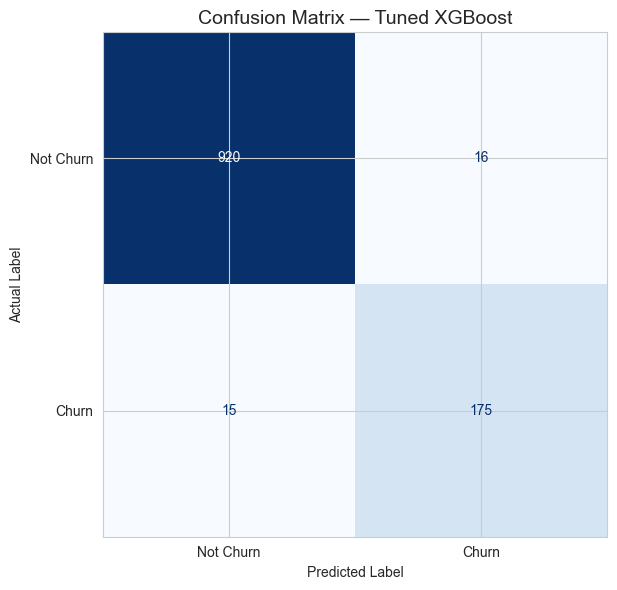

Saved -> ../plots/confusion_matrix_final_tuned_model.png

TN = 920, FP = 16, FN = 15, TP = 175


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

sns.set_style('whitegrid')

# ---------------------------------------------------------
# 9a. Confusion Matrix — Selected Final Tuned Model
# ---------------------------------------------------------
final_cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=['Not Churn', 'Churn']
)

disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d'
)

ax.set_title(
    f'Confusion Matrix — Tuned {best_model_name}',
    fontsize=14
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')

plt.tight_layout()

plot_path = '../plots/confusion_matrix_final_tuned_model.png'
plt.savefig(
    plot_path,
    dpi=120,
    bbox_inches='tight'
)

plt.show()
print(f"Saved -> {plot_path}")

tn, fp, fn, tp = final_cm.ravel()
print(f"\nTN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")


This confusion matrix shows the errors made by the **selected final tuned model** on the untouched test set.

- **TN (True Negative):** correctly predicted non-churn customers.
- **FP (False Positive):** predicted churn, but the customer did not churn.
- **FN (False Negative):** predicted non-churn, but the customer actually churned.
- **TP (True Positive):** correctly predicted churn customers.

For the project defense, read the exact TN, FP, FN, and TP values printed by the executed cell rather than using older hard-coded XGBoost counts.

Model comparison bar chart — **AUC-ROC of the four tuned models only**.

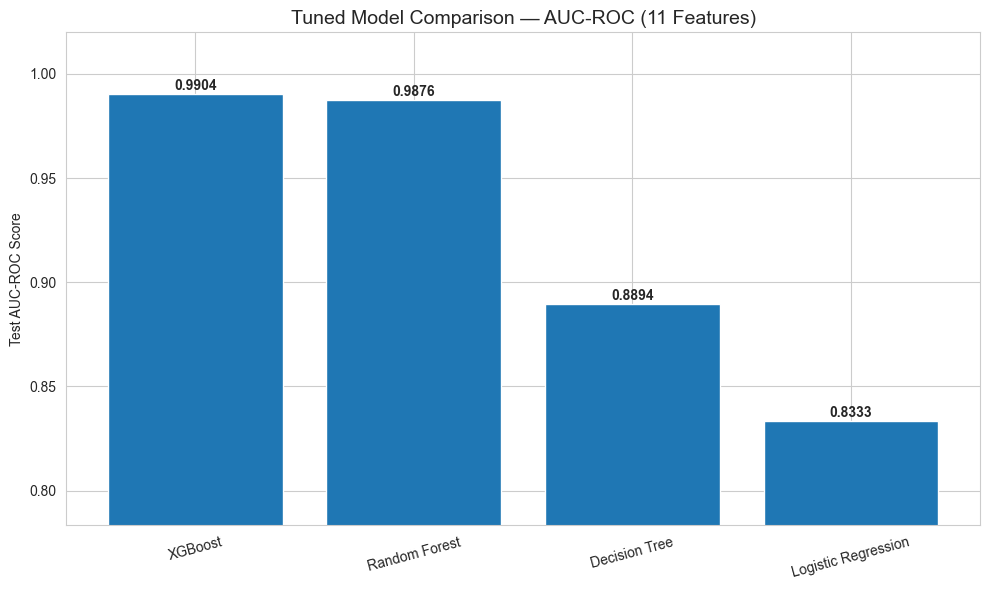

Saved -> ../plots/tuned_model_comparison_11features.png

Only the best tuned version of each algorithm is included in this chart.


In [20]:
# ---------------------------------------------------------
# 9b. Model Comparison — AUC-ROC of tuned models only
# ---------------------------------------------------------
plot_df = comparison_df.sort_values('Test AUC-ROC', ascending=False).copy()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    plot_df['Model'],
    plot_df['Test AUC-ROC']
)

for bar, score in zip(bars, plot_df['Test AUC-ROC']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{score:.4f}',
        ha='center',
        fontweight='bold'
    )

lower_bound = max(0, plot_df['Test AUC-ROC'].min() - 0.05)
ax.set_ylim(lower_bound, 1.02)
ax.set_ylabel('Test AUC-ROC Score')
ax.set_title('Tuned Model Comparison — AUC-ROC (11 Features)', fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()

plot_path = '../plots/tuned_model_comparison_11features.png'
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()

print(f"Saved -> {plot_path}")
print("\nOnly the best tuned version of each algorithm is included in this chart.")


### Tuned Model Comparison — AUC-ROC Score (11 features)

This chart contains **four bars only**: one for the best tuned Logistic Regression, Decision Tree, Random Forest, and XGBoost model.

A higher AUC-ROC means the model is better at ranking churners above non-churners across classification thresholds.

Because every bar represents a model that was already tuned with 5-fold cross-validation, this is a much fairer comparison than mixing default and tuned models.

Feature importance / coefficient magnitude chart for the **selected final tuned model**.

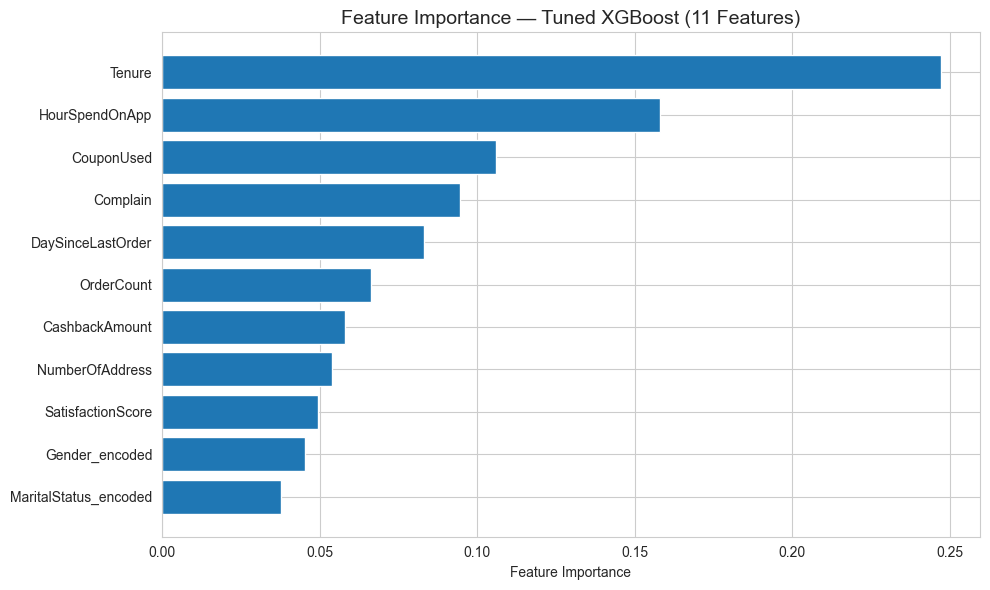

Saved -> ../plots/feature_importance_final_tuned_model.png

--- All 11 features ranked ---
              feature  importance
               Tenure    0.247276
       HourSpendOnApp    0.158150
           CouponUsed    0.105911
             Complain    0.094589
    DaySinceLastOrder    0.083034
           OrderCount    0.066316
       CashbackAmount    0.057956
      NumberOfAddress    0.053994
    SatisfactionScore    0.049604
       Gender_encoded    0.045302
MaritalStatus_encoded    0.037869


In [21]:
# ---------------------------------------------------------
# 9c. Feature Importance — Selected Final Tuned Model
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The saved best_model is an imblearn Pipeline:
#   SMOTE -> fitted classifier
final_classifier = best_model.named_steps['model']
feature_names = X_train.columns

if hasattr(final_classifier, 'feature_importances_'):
    importance_values = final_classifier.feature_importances_
    importance_label = 'Feature Importance'
elif hasattr(final_classifier, 'coef_'):
    # For Logistic Regression, use absolute coefficient magnitude
    importance_values = np.abs(final_classifier.coef_[0])
    importance_label = 'Absolute Coefficient Magnitude'
else:
    importance_values = None

if importance_values is not None:
    imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_values
    }).sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        imp_df['feature'][::-1],
        imp_df['importance'][::-1]
    )
    ax.set_xlabel(importance_label)
    ax.set_title(
        f'Feature Importance — Tuned {best_model_name} (11 Features)',
        fontsize=14
    )
    plt.tight_layout()

    plot_path = '../plots/feature_importance_final_tuned_model.png'
    plt.savefig(plot_path, dpi=120, bbox_inches='tight')
    plt.show()

    print(f"Saved -> {plot_path}")
    print("\n--- All 11 features ranked ---")
    print(imp_df.to_string(index=False))
else:
    print(
        f"{best_model_name} does not expose built-in feature_importances_ "
        "or coef_. No built-in importance chart was generated."
    )


### Feature Importance — Selected Final Tuned Model

The chart above is generated from whichever tuned model is selected as the final model.

- For **Decision Tree, Random Forest, or XGBoost**, the model's built-in `feature_importances_` values are used.
- For **Logistic Regression**, the absolute coefficient magnitudes are shown instead.
- Larger values mean the trained model relied more strongly on that feature for prediction.
- These values show predictive contribution, **not causation**.

10. Saving the final model artifacts

The notebook saves the **selected final tuned model pipeline**, not an untuned model.

What is saved:

- `churn_model.pkl` — the complete final pipeline containing SMOTE configuration and the selected tuned classifier.
- `feature_columns.pkl` — the exact 11-feature column order expected at prediction time.
- `encoding_maps.pkl` — the Gender and MaritalStatus encoding mappings used by the project.

The fitted pipeline skips SMOTE during prediction; SMOTE is only used during fitting.